# Session tunnel — `enter_new_flow_run` from a local notebook

Each cell below opens a **real child flow run on the Runner** and writes into it from
local code. Inside a `with blt.enter_new_flow_run(...)` block:

- `plt.show()` ships the figure to *that* run (and still renders inline here),
- `blt.output[...]` writes land on *that* run,
- `device.params.update(...)` writes are attributed to *that* run,
- `blt.params` / `blt.devices` reflect what you passed in,
- an exception marks the run **FAILED** and re-raises — no bookkeeping from you.

**Before running:** start `flows/tunnel_session_server.py` as a flow in Balthazar.
This notebook must be opened with `session_tunnel/` as the working directory so
`import balthazar` resolves to the v2 shim here, not the v1 shim one level up.

## 0. Connect

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import balthazar as blt

# A real space has plenty of devices, and devices[0] is whatever sorts first.
# Narrow the selection here, and cap how many child runs the batch example makes —
# otherwise it opens one per device and floods the run list.
DEVICE_TYPE = None      # e.g. "Instrument" or "Wafer"; None = any type
DEVICE_NAME = None      # e.g. "Instrument_QCCS-*" (glob); None = any name
MAX_BATCH_DEVICES = 2   # child runs created by the nested example

info = blt.ping()
print(f"connected to flow {info['flow_name']!r}")
print(f"context depth     {info['depth']} (0 = nothing open)")

all_devices = blt.search_devices(type=DEVICE_TYPE, name=DEVICE_NAME)
assert all_devices, f"no devices match type={DEVICE_TYPE!r} name={DEVICE_NAME!r}"

devices = all_devices[:MAX_BATCH_DEVICES]
device = devices[0]
baseline_yield = float(dict(device.params).get("yield_pct", 50.0))

print(f"matched           {len(all_devices)} device(s), using {len(devices)}")
print(f"selected          {', '.join(d.name for d in devices)}")
print(f"primary           {device.name} (type {device.type}, yield {baseline_yield}%)")

connected to flow 'Tunnel Server - Advanced'
context depth     0 (0 = nothing open)
matched           65 device(s), using 2
selected          dummy, Instrument_QCCS-001
primary           dummy (type dummy, yield 50.0%)


## 1. One context — plot and output land on the open run

Note what `blt.params` and `blt.devices` report *inside* the block: the child run's
own inputs, not the tunnel flow's. The Runner rebinds those globals on entering a
child run, and the shim mirrors that.

run          019ff57f-8da6-7532-83a4-d340c66a1d81
blt.params   {'bias_min_v': -1.0, 'bias_max_v': 1.0, 'points': 201}
blt.devices  ['dummy']


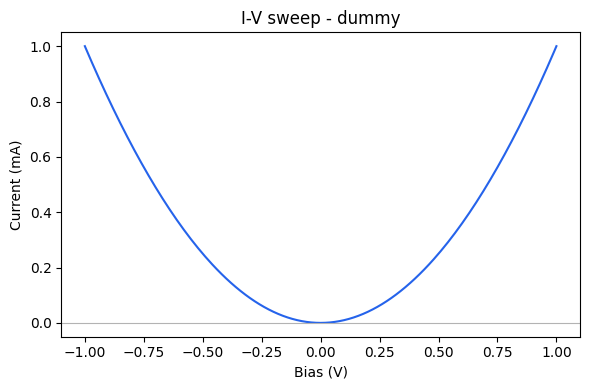

blt.output   {'i_at_1v_ma': 1.0, 'zero_bias_resistance_ohm': -inf, 'status': 'success'}


In [7]:
bias = np.linspace(-1.0, 1.0, 201)
current = bias ** 2

with blt.enter_new_flow_run(
    name="sweep: single context",
    devices=[device],
    parameters={"bias_min_v": -1.0, "bias_max_v": 1.0, "points": bias.size},
) as run:
    print(f"run          {run.flow_run_id}")
    print(f"blt.params   {dict(blt.params)}")
    print(f"blt.devices  {[d.name for d in blt.devices]}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(bias, current, color="#2563eb")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xlabel("Bias (V)")
    ax.set_ylabel("Current (mA)")
    ax.set_title(f"I-V sweep - {device.name}")
    fig.tight_layout()
    plt.show()   # uploads to THIS run, then renders inline below

    blt.output["i_at_1v_ma"] = round(float(current[-1]), 4)
    blt.output.update({
        "zero_bias_resistance_ohm": round(float(np.gradient(bias, current)[100]), 4),
        "status": "success",
    })
    print(f"blt.output   {dict(blt.output.items())}")

## 2. Nested contexts — a parent run with one child per device

This is the orchestrator shape: a parent run that spawns a child per item, each with
its own inputs, plot and output, every one attributable in the UI. `blt.parent()` and
`blt.parents()` tell you where you are.

parent 019ff59d-d261-7e20-bb43-c732e5f677db
  child 019ff59d for dummy (depth 2, parent 'batch: all devices')


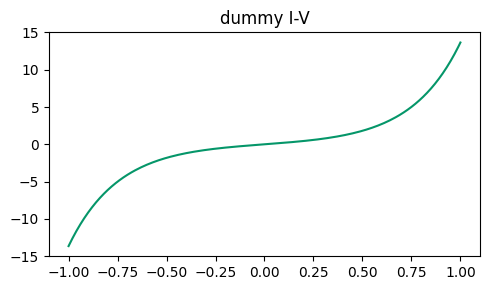

  child 019ff59d for Instrument_QCCS-001 (depth 2, parent 'batch: all devices')


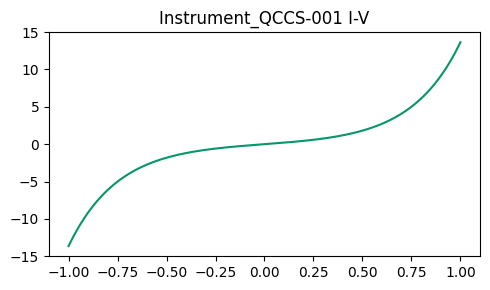

parent output {'children': 2, 'peak_max_ma': 13.645, 'status': 'success'}


In [ ]:
with blt.enter_new_flow_run(
    name="batch: all devices",
    #flow_id="019ce6f1-c86f-7d63-8f74-b2fbb040cd79",
    devices=devices,
    parameters={"device_count": len(devices), "mode": "batch"},
) as batch:
    print(f"parent {batch.flow_run_id}")
    peaks = []

    for d in devices:
        d_yield = float(dict(d.params).get("yield_pct", 50.0))
        with blt.enter_new_flow_run(
            name=f"sweep: {d.name}",
            flow_id="019ce6f1-c86f-7d63-8f74-b2fbb040cd79",
            devices=[d],
            parameters={"device": d.name, "yield_pct": d_yield},
        ) as child:
            print(f"  child {child.flow_run_id[:8]} for {d.name} "
                  f"(depth {len(blt.parents()) + 1}, parent {blt.parent()['name']!r})")

            i = np.sinh(bias * 4.0) * d_yield / 100.0
            fig, ax = plt.subplots(figsize=(5, 3))
            ax.plot(bias, i, color="#059669")
            ax.set_title(f"{d.name} I-V")
            fig.tight_layout()
            plt.show()

            blt.output.update({"peak_ma": round(float(i.max()), 4), "status": "success"})
            peaks.append(float(i.max()))

    # Back in the parent context, so this output lands on the parent run.
    blt.output.update({
        "children": len(devices),
        "peak_max_ma": round(max(peaks), 4),
        "status": "success",
    })
    print(f"parent output {dict(blt.output.items())}")

## 3. Writing device params from inside a run

The measurement-flow pattern: results are fields on the measured device, and the write
is attributed to the run that produced them.

`update()` is the only reliable write path — on the real proxy a subscript assignment
does not sync, notably for dict values, so the shim raises instead of losing the write.
Nested changes rebuild the whole top-level key rather than mutating in place.

In [ ]:
with blt.enter_new_flow_run(
    name="measure: write back to device",
    devices=[device],
    parameters={"probe": "4-point", "temperature_k": 297.0},
):
    measurements = dict(dict(device.params).get("measurements", {}))
    measurements["iv_sweep"] = {
        "i_at_1v_ma": round(float(current[-1]), 4),
        "probe": "4-point",
    }
    device.params.update({"measurements": measurements})
    blt.output.update({"keys_written": 1, "status": "success"})

print(f"device.params now {dict(device.params)['measurements']}")

# What a subscript write does instead of silently vanishing:
try:
    device.params["measurements"] = {}
except NotImplementedError as exc:
    print(f"\nsubscript refused: {str(exc)[:96]}...")

## 4. An exception marks the run FAILED

No status bookkeeping. The Runner's context `__exit__` derives the status from the
exception in flight, records its message, and re-raises — so you handle the error
locally exactly as you would in a deployed flow.

In [ ]:
try:
    with blt.enter_new_flow_run(
        name="sweep: aborted by exception",
        devices=[device],
        parameters={"bias_max_v": 5.0, "compliance_ma": 10.0},
    ):
        blt.output.update({"aborted_at_v": 3.2})
        raise RuntimeError("compliance limit hit at 3.2 V")
except RuntimeError as exc:
    print(f"caught locally: {exc}")
    print("the run is FAILED in Balthazar with that message attached")

print(f"context depth back to {blt.context()['depth']}")

## 5. Failing a run without raising

When you want the run red but do not want an exception in your notebook flow, close it
with `fail()`. Manual `enter` / `exit` also works, mirroring the real API.

In [ ]:
run = blt.enter_new_flow_run(name="sweep: explicitly failed", devices=[device])
blt.output.update({"reason": "instrument offline"})
run.fail("instrument offline: no GPIB response")
print(f"run {run.flow_run_id} closed as FAILED")
print(f"context depth {blt.context()['depth']}")

## 6. Recovery

If a kernel dies inside a `with` block, the run is left open on the server. Two
backstops: the server's idle watchdog unwinds abandoned contexts (`idle_timeout`, 30
min by default), and `reset_contexts()` forces it immediately. The shim also closes
open contexts on interpreter exit.

Restarting the kernel mid-context is the case to remember — run this cell then.

In [ ]:
print(f"server context depth: {blt.context()['depth']}")
# blt.reset_contexts("kernel restarted mid-context")   # uncomment if a run is stuck

blt.info("session-tunnel notebook demo finished")
print("check the tunnel flow's run tree in Balthazar")